In [6]:
import numpy as np
from matplotlib import pyplot as plt

Traffic delay: 0.0015
Propagation delay5e-07
Traffic intensity1.23


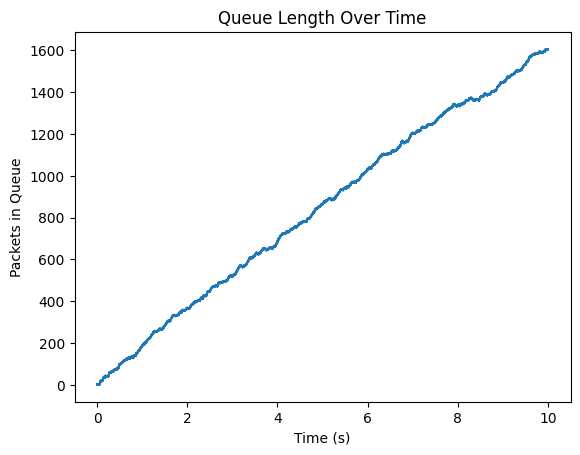

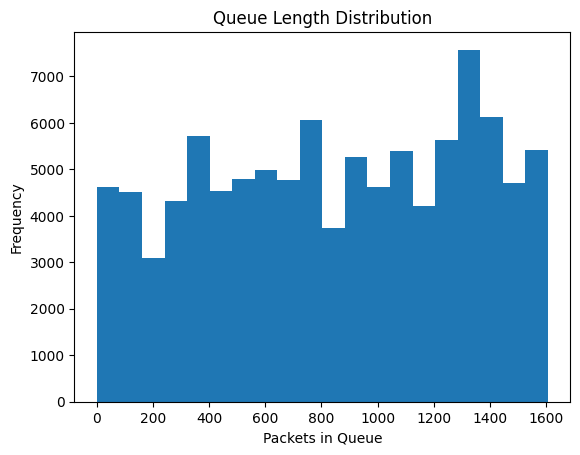

In [7]:
def simulate_network(L, R, d, s, lam, steps=100000):
    tra_delay = L/R
    pro_delay =d/s
    traf_intensity= lam* tra_delay
    print("Traffic delay: "+str(tra_delay))
    print("Propagation delay"+str(pro_delay))
    print("Traffic intensity"+str(traf_intensity))
    queue = np.zeros(steps)
    dt = 0.0001
    server_busy_until = 0 
    queue_delays= []
    for t in range(1,steps):
        current_time = t * dt
        arrivals = np.random.poisson(lam*dt)
        if queue[t-1] > 0 and current_time >= server_busy_until:
            sent = 1  
            server_busy_until = current_time + tra_delay 
        else:
            sent = 0
    
    
        queue[t]=max(queue[t-1]+arrivals-sent,0)
    time = np.arange(steps)*dt
    plt.plot(time,queue)
    plt.title("Queue Length Over Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Packets in Queue")
    plt.show()

    plt.hist(queue, bins=20)
    plt.title("Queue Length Distribution")
    plt.xlabel("Packets in Queue")
    plt.ylabel("Frequency")
    plt.show()
simulate_network(L,R,d,s,lam)


In [5]:

def simulate_network_v2(L, R, d, s, lam, steps=100000):
    tra_delay = L / R
    pro_delay = d / s
    traf_intensity = lam * tra_delay
    print("Traffic delay: "+str(tra_delay))
    print("Propagation delay: "+str(pro_delay))
    print("Traffic intensity: "+str(traf_intensity))

    dt = 0.0001
    server_busy_until = 0
    queue_list = []  # 
    queue_lengths = np.zeros(steps)
    queue_delays = []
    K= 300
    dropped_packets = 0
    drop_over_time = np.zeros(steps)

    for t in range(steps):
        current_time = t * dt
        arrivals = np.random.poisson(lam * dt)

        # Adding arriving packets to the queue
        for _ in range(arrivals):
            if len(queue_list) < K:
                queue_list.append(current_time)
            else:
                dropped_packets += 1

        
        while queue_list and current_time >= server_busy_until:
            arrival_time = queue_list.pop(0)
            wait_time = max(0, server_busy_until - arrival_time)
            server_busy_until = max(current_time, server_busy_until) + tra_delay
            queue_delays.append(wait_time)

        # Dropped packets and queue_length recording
        queue_lengths[t] = len(queue_list)
        drop_over_time[t] = dropped_packets

    if queue_delays:
        print(f"Average queue delay: {np.mean(queue_delays):.6f}")
    else:
        print("Average queue delay: 0")

    time = np.arange(steps) * dt

    # Queue Length Over Time
    plt.figure(figsize=(10,4))
    plt.plot(time, queue_lengths, color='blue')
    plt.title("Queue Length Over Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Packets in Queue")
    plt.grid(True)
    plt.savefig("images/congested_queue_length_over_time.png", dpi=300)
    plt.close()


    # Queue Length Distribution
    plt.figure(figsize=(6,4))
    plt.hist(queue_lengths, bins=20, color='orange', edgecolor='black')
    plt.title("Queue Length Distribution")
    plt.xlabel("Packets in Queue")
    plt.ylabel("Frequency")
   
    plt.savefig("images/congested_queue_length_distribution.png", dpi=300)
    plt.close()

    # Queue Delay Distribution
    plt.figure(figsize=(6,4))
    plt.hist(queue_delays, bins=30, color='skyblue', edgecolor='black')
    plt.title("Queue Delay Distribution")
    plt.xlabel("Queue Delay (s)")
    plt.ylabel("Frequency")
    plt.savefig("images/congested_queue_delay_distribution.png", dpi=300)
    plt.close()
    # Drop Count Over Time
    plt.figure(figsize=(10,4))
    plt.plot(time, drop_over_time,color="green")
    plt.title("Dropped Packets Over Time")
    plt.xlabel("Time (s)")
    plt.ylabel("Total Dropped Packets")
    plt.grid(True)
    plt.savefig("images/congested_drop_over_time.png", dpi=300)
    plt.close()
    with open("images/congested_simulation_results.txt", "w") as f:
        f.write(f"Traffic delay: {tra_delay}\n")
        f.write(f"Propagation delay: {pro_delay}\n")
        f.write(f"Traffic intensity (rho): {traf_intensity}\n")
        f.write(f"Average queue delay: {np.mean(queue_delays) if queue_delays else 0}\n")
        f.write(f"Total dropped packets: {dropped_packets}\n")

# Parameters
L = 1500    # Packet size (bits)
R = 1e6    # Transfer rate (bits/s)
d = 100     # distance (meters)
s = 2e8     # speed (m/s)
lam = 820   # Arrival rate (packets/s)

simulate_network_v2(L, R, d, s, lam)


Traffic delay: 0.0015
Propagation delay: 5e-07
Traffic intensity: 1.23
Average queue delay: 0.407453
